regression, residual = anomaly score

In [1]:
import pandas as pd; import numpy as np; import matplotlib.pyplot as plt; import seaborn as sns; from sklearn.preprocessing import StandardScaler, OneHotEncoder; from sklearn.compose import ColumnTransformer; from sklearn.pipeline import Pipeline; from sklearn.ensemble import HistGradientBoostingRegressor; from sklearn.model_selection import cross_val_predict, KFold; from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score; from sklearn.inspection import permutation_importance

In [2]:
df = pd.read_csv('repair_invoice_clean.csv')
df.head()

,repair_id,claim_id,vehicle_id,repair_shop_contact_id,estimate_amount,approved_amount,invoice_amount,paid_amount,repair_start_date,repair_end_date,...,exposure_status,is_repeat_vehicle,is_synthetic_anomaly,anomaly_type,vehicle_claim_count,repair_duration_days,vehicle_age,invoice_vs_estimate_ratio,invoice_vs_approved_ratio,duplicate_flag
0,1,1,5749,217,883.00,859.88,821.28,779.60,2025-11-16,2025-11-18,...,Open,False,False,NaN,1,2,13,0.930102,0.955110,True
1,2,2,1818,152,1659.62,1620.74,1627.69,1621.15,2026-02-23,2026-03-02,...,Closed,False,False,NaN,1,7,6,0.980761,1.004288,False
2,7,6,4529,175,1013.25,844.58,917.77,820.13,2026-04-06,2026-04-12,...,Open,False,False,NaN,1,6,3,0.905769,1.086658,False
3,8,6,4529,175,1231.42,1213.63,1417.89,1211.47,2026-04-06,2026-04-12,...,Open,False,False,NaN,1,6,3,1.151427,1.168305,False
4,9,7,7329,180,2946.86,3039.04,2827.41,2918.91,2025-11-23,2025-11-29,...,Closed,False,False,NaN,1,6,4,0.959465,0.930363,False


In [3]:
NUMERIC_FEATURES = ["estimate_amount", "vehicle_age", "liability_percentage", "repair_duration_days", "vehicle_claim_count"]
CATEGORICAL_FEATURES = ["make", "damage_severity", "claim_severity", "incident_type", "incident_state", "coverage_type"]
TARGET = "invoice_amount"

In [4]:
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

In [5]:
pre = ColumnTransformer([("num", StandardScaler(), NUMERIC_FEATURES), ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)])

In [6]:
# lightgbm/xgboost need libomp, not on this machine, using sklearn GBM instead
model = Pipeline([("pre", pre), ("gbm", HistGradientBoostingRegressor(random_state=42))])

In [7]:
oof_pred = cross_val_predict(model, X, y, cv=KFold(5, shuffle=True, random_state=42))

In [8]:
print("MAE", mean_absolute_error(y, oof_pred))
print("RMSE", mean_squared_error(y, oof_pred) ** 0.5)
print("R2", r2_score(y, oof_pred))

MAE 378.70809495379234
RMSE 1061.7368959836815
R2 0.8708602089184105


In [9]:
df["residual"] = y.values - oof_pred
FLAG_PCT = 95
threshold = np.percentile(np.abs(df["residual"]), FLAG_PCT)

In [10]:
df["reg_flag"] = df["residual"].abs() > threshold
df["reg_flag"].value_counts()

reg_flag
False    6133
True      323
Name: count, dtype: int64

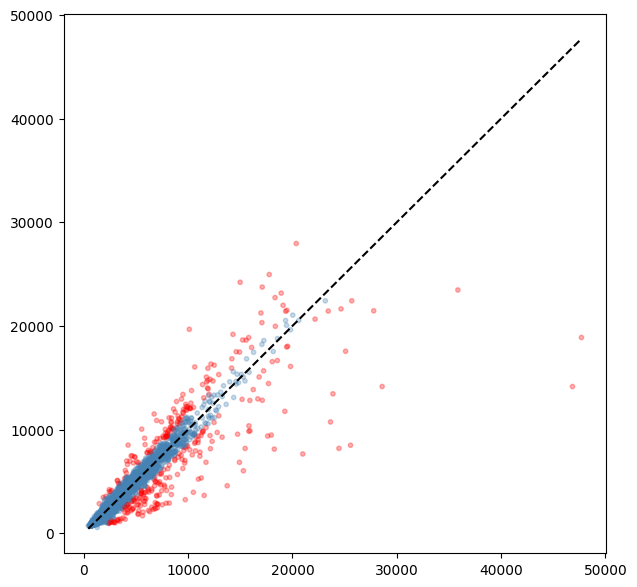

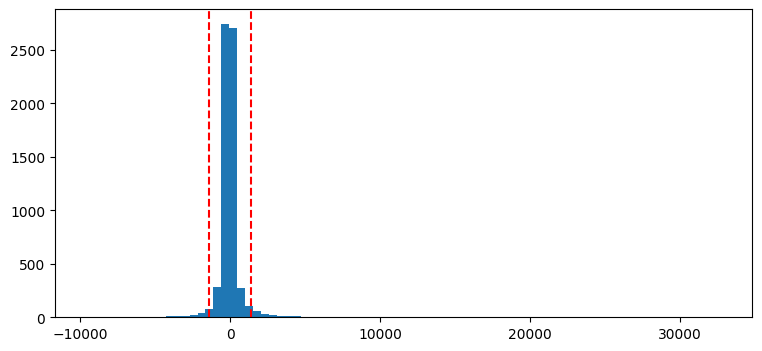

In [11]:
fig, ax = plt.subplots(figsize=(7, 7)); ax.scatter(y, oof_pred, s=10, alpha=0.3, c=df["reg_flag"].map({True: "red", False: "steelblue"})); lims = [y.min(), y.max()]; ax.plot(lims, lims, "k--"); plt.show(); fig, ax = plt.subplots(figsize=(9, 4)); ax.hist(df["residual"], bins=80); ax.axvline(threshold, color="red", ls="--"); ax.axvline(-threshold, color="red", ls="--"); plt.show()

In [12]:
model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('gbm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['estimate_amount','vehicle_age','liability_percentage',..., 'incident_type','incident_state','coverage_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

In [13]:
imp = permutation_importance(model, X, y, n_repeats=5, random_state=42, scoring="neg_mean_absolute_error")
order = np.argsort(imp.importances_mean)[::-1]

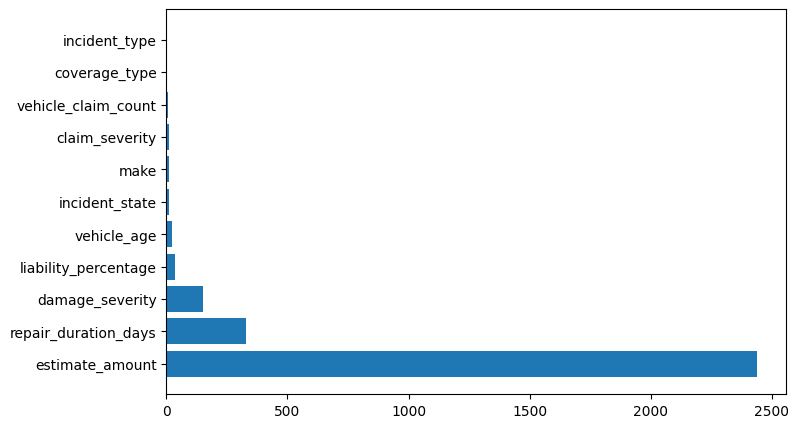

In [14]:
fig, ax = plt.subplots(figsize=(8, 5)); ax.barh(np.array(X.columns)[order], imp.importances_mean[order]); plt.show()

In [15]:
ct = pd.crosstab(df["reg_flag"], df["duplicate_flag"], normalize="index")
print(ct.round(3))
print(df.loc[df["reg_flag"], "duplicate_flag"].mean(), df["duplicate_flag"].mean())

duplicate_flag  False  True 
reg_flag                    
False           0.917  0.083
True            0.969  0.031
0.030959752321981424 0.07992565055762081


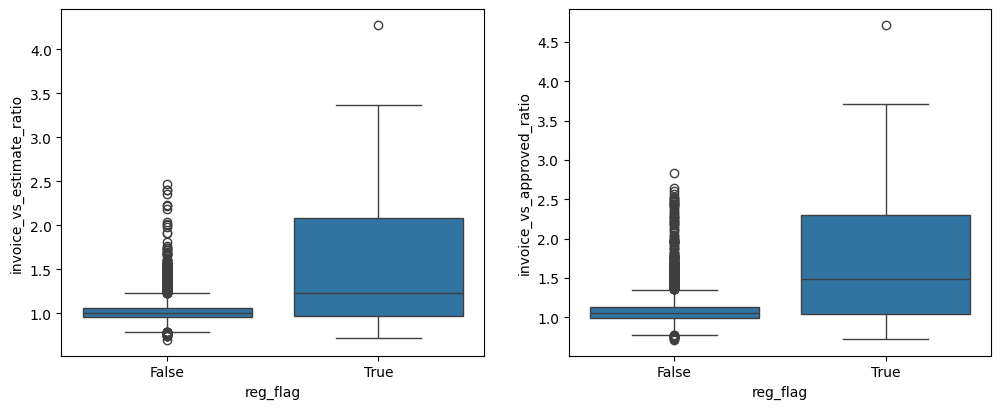

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col in zip(axes, ["invoice_vs_estimate_ratio", "invoice_vs_approved_ratio"]):
    sns.boxplot(data=df, x="reg_flag", y=col, ax=ax)
plt.show()

In [17]:
def score_new_point(record, actual_invoice):
    row = pd.DataFrame([record])[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
    pred = model.predict(row)[0]
    resid = actual_invoice - pred
    return {"predicted": pred, "actual": actual_invoice, "residual": resid, "threshold": threshold, "reg_flag": abs(resid) > threshold}

In [18]:
typical_point = {"estimate_amount": 2265.50, "vehicle_age": 9, "liability_percentage": 85.0, "repair_duration_days": 6, "vehicle_claim_count": 1,
    "make": "Toyota", "damage_severity": "Moderate", "claim_severity": "Medium", "incident_type": "Vehicle Accident", "incident_state": "CA", "coverage_type": "Liability"}

suspicious_point = {"estimate_amount": 2400.00, "vehicle_age": 2, "liability_percentage": 22.0, "repair_duration_days": 6, "vehicle_claim_count": 1,
    "make": "Tesla", "damage_severity": "Minor", "claim_severity": "Low", "incident_type": "Vehicle Accident", "incident_state": "CA", "coverage_type": "Liability"}

In [19]:
print("typical", score_new_point(typical_point, 2320.00))
print("suspicious", score_new_point(suspicious_point, 18250.00))

typical {'predicted': 2386.1797529036203, 'actual': 2320.0, 'residual': -66.17975290362028, 'threshold': 1367.827591825483, 'reg_flag': False}
suspicious {'predicted': 2946.9965642634993, 'actual': 18250.0, 'residual': 15303.0034357365, 'threshold': 1367.827591825483, 'reg_flag': True}
